# Feature importance from ML models (research columns)

We use the **imputed research columns** (`ml_households_research_columns_imputed.csv`, 27–28 columns) to train several ML models predicting **household_income_total** (regression). For each model we extract feature importance (or coefficients), save results to **separate CSVs**, and plot visualizations.

**Target:** `household_income_total` (Armenian Drams, AMD)  
**Features:** All other numeric columns from the research set (27 features).  
**Output:** One CSV per model in `data/ilcs/research/feature_importance/`, plus bar charts and a comparison plot.

## 1. Load data and prepare target and features

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ilcs"
RESEARCH_CSV = DATA_DIR / "research" / "ml_households_research_columns_imputed.csv"
OUT_DIR = DATA_DIR / "research" / "feature_importance"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "household_income_total"
df = pd.read_csv(RESEARCH_CSV, low_memory=False)
feature_cols = [c for c in df.columns if c != TARGET and np.issubdtype(df[c].dtype, np.number)]
X = df[feature_cols]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Target: {TARGET}")
print(f"Features: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Target: household_income_total
Features: 27
Train: 4,147 | Test: 1,037


## 2. Random Forest — feature importance

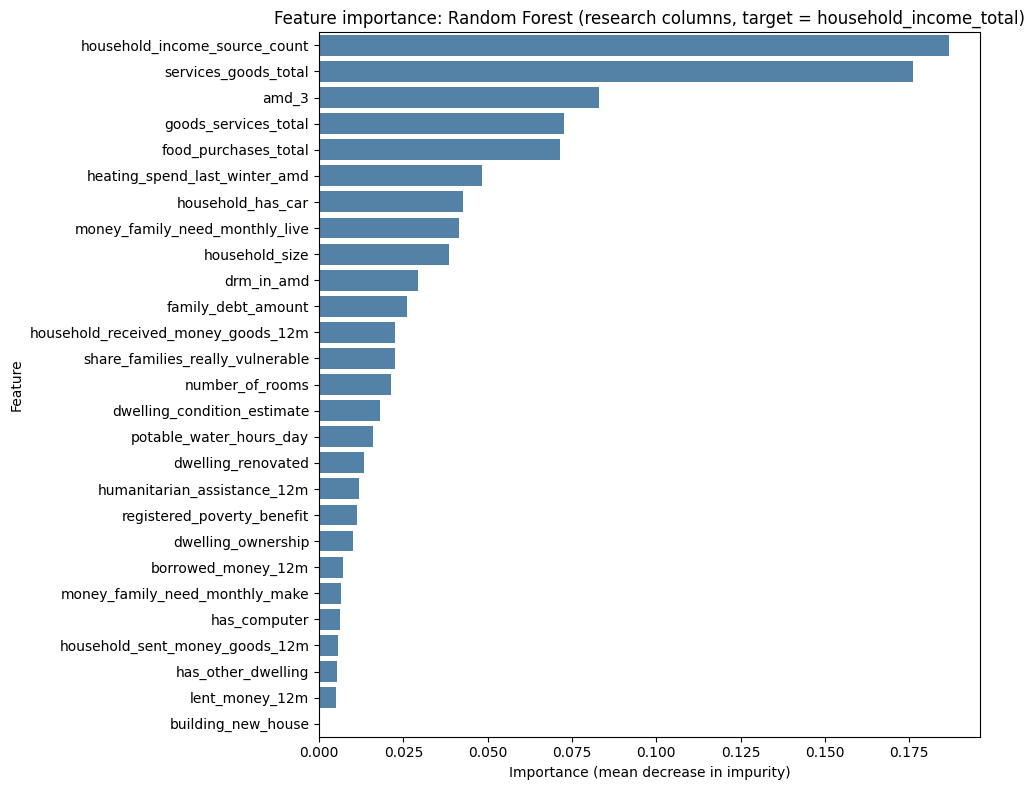

Saved: /Users/hovosukiasyan/Capstone/data/ilcs/research/feature_importance/feature_importance_rf.csv


In [2]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_s, y_train)
imp_rf = pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
imp_rf.to_csv(OUT_DIR / "feature_importance_rf.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_rf, y="feature", x="importance", ax=ax, color="steelblue")
ax.set_title("Feature importance: Random Forest (research columns, target = household_income_total)")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_rf.csv'}")

## 3. Gradient Boosting — feature importance

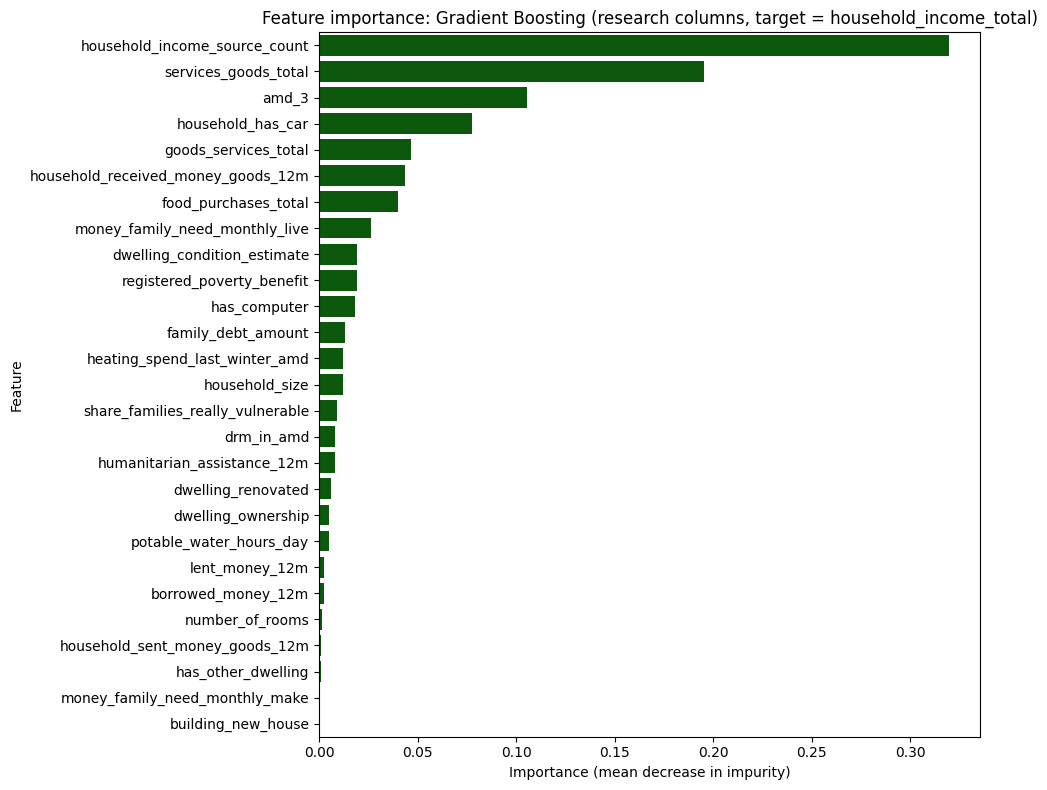

Saved: /Users/hovosukiasyan/Capstone/data/ilcs/research/feature_importance/feature_importance_gbm.csv


In [3]:
gbm = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbm.fit(X_train_s, y_train)
imp_gbm = pd.DataFrame({"feature": feature_cols, "importance": gbm.feature_importances_}).sort_values("importance", ascending=False)
imp_gbm.to_csv(OUT_DIR / "feature_importance_gbm.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_gbm, y="feature", x="importance", ax=ax, color="darkgreen")
ax.set_title("Feature importance: Gradient Boosting (research columns, target = household_income_total)")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_gbm.csv'}")

## 4. Extra Trees — feature importance

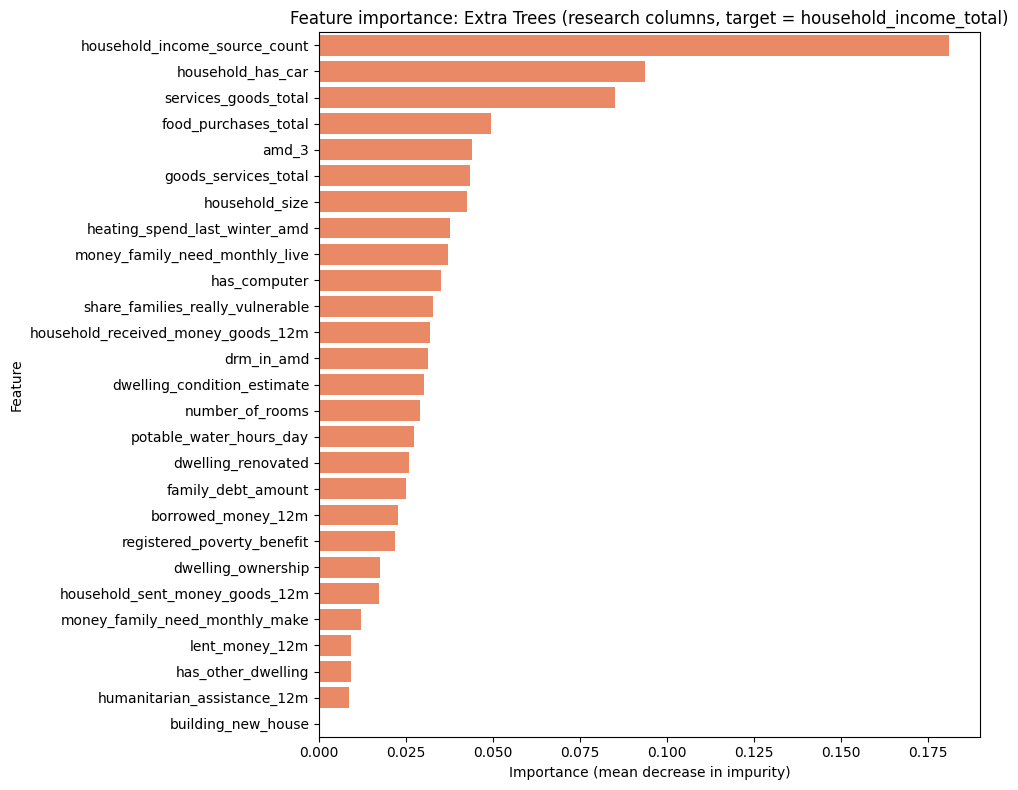

Saved: /Users/hovosukiasyan/Capstone/data/ilcs/research/feature_importance/feature_importance_extra_trees.csv


In [4]:
et = ExtraTreesRegressor(n_estimators=100, random_state=42)
et.fit(X_train_s, y_train)
imp_et = pd.DataFrame({"feature": feature_cols, "importance": et.feature_importances_}).sort_values("importance", ascending=False)
imp_et.to_csv(OUT_DIR / "feature_importance_extra_trees.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_et, y="feature", x="importance", ax=ax, color="coral")
ax.set_title("Feature importance: Extra Trees (research columns, target = household_income_total)")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_extra_trees.csv'}")

## 5. Ridge — coefficient magnitude as importance

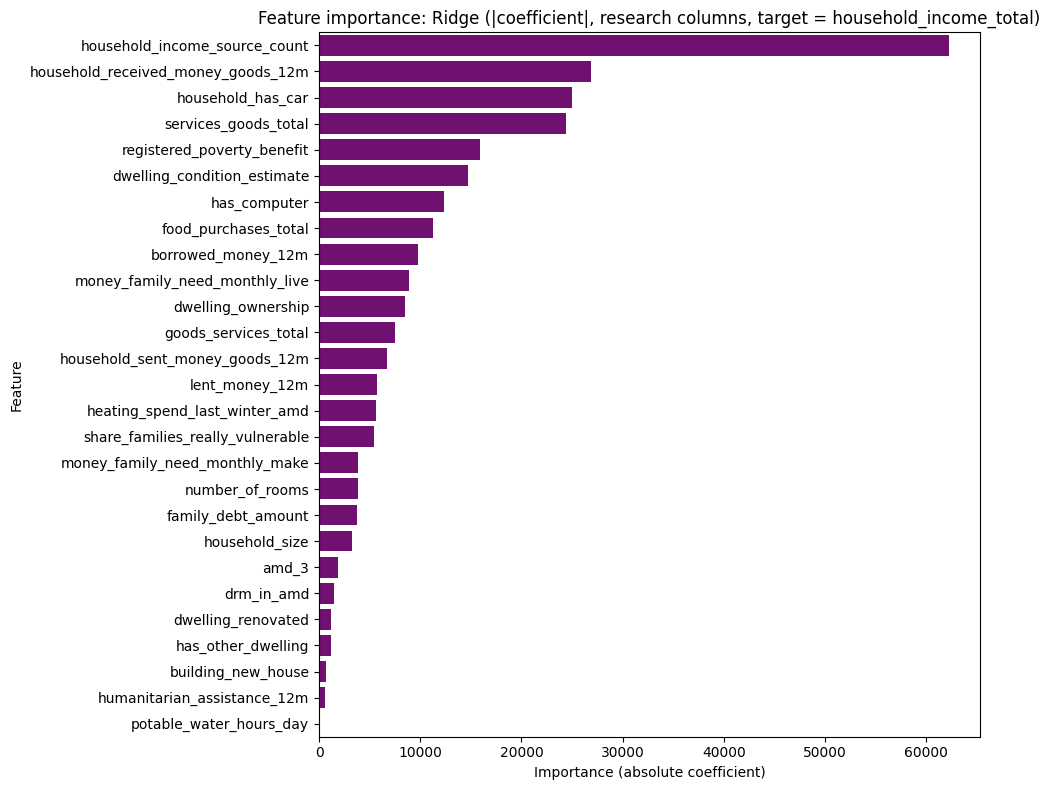

Saved: /Users/hovosukiasyan/Capstone/data/ilcs/research/feature_importance/feature_importance_ridge.csv


In [5]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
imp_ridge = pd.DataFrame({"feature": feature_cols, "importance": np.abs(ridge.coef_)}).sort_values("importance", ascending=False)
imp_ridge.to_csv(OUT_DIR / "feature_importance_ridge.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_ridge, y="feature", x="importance", ax=ax, color="purple")
ax.set_title("Feature importance: Ridge (|coefficient|, research columns, target = household_income_total)")
ax.set_xlabel("Importance (absolute coefficient)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_ridge.csv'}")

## 6. Lasso — coefficient magnitude as importance

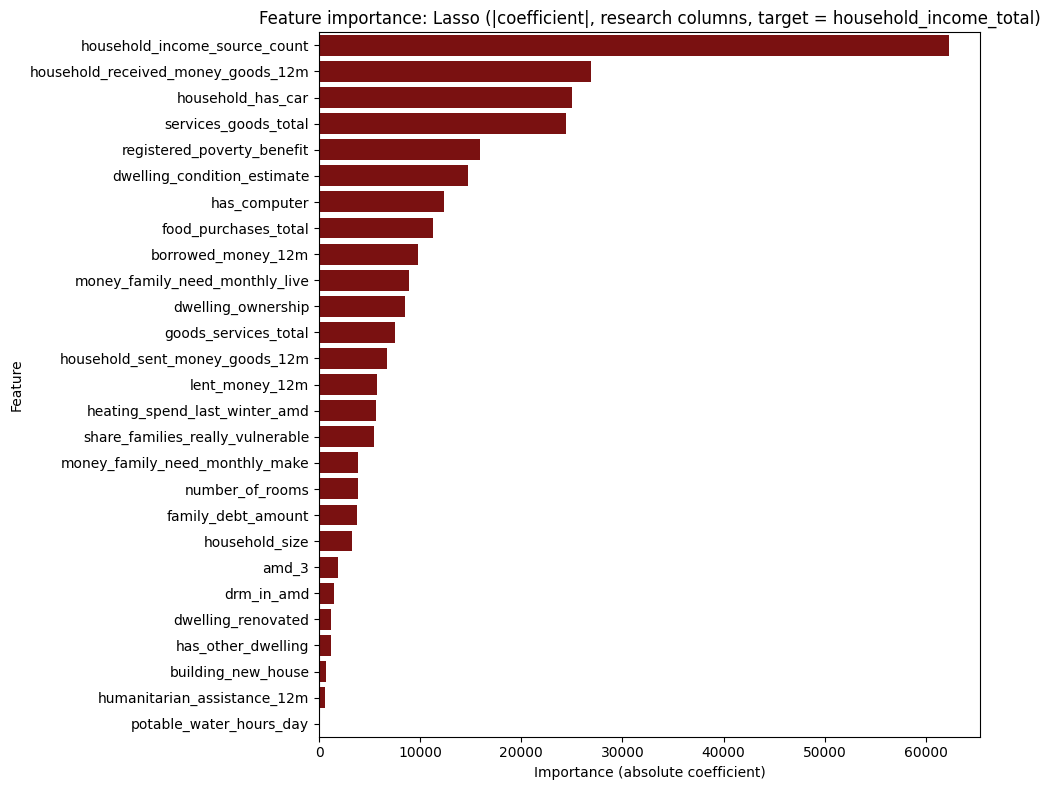

Saved: /Users/hovosukiasyan/Capstone/data/ilcs/research/feature_importance/feature_importance_lasso.csv


In [6]:
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train_s, y_train)
imp_lasso = pd.DataFrame({"feature": feature_cols, "importance": np.abs(lasso.coef_)}).sort_values("importance", ascending=False)
imp_lasso.to_csv(OUT_DIR / "feature_importance_lasso.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_lasso, y="feature", x="importance", ax=ax, color="darkred")
ax.set_title("Feature importance: Lasso (|coefficient|, research columns, target = household_income_total)")
ax.set_xlabel("Importance (absolute coefficient)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_lasso.csv'}")

## 7. Comparison across models

We merge importance from all models and plot a grouped bar chart (top features) and a heatmap (all features, normalized per model).

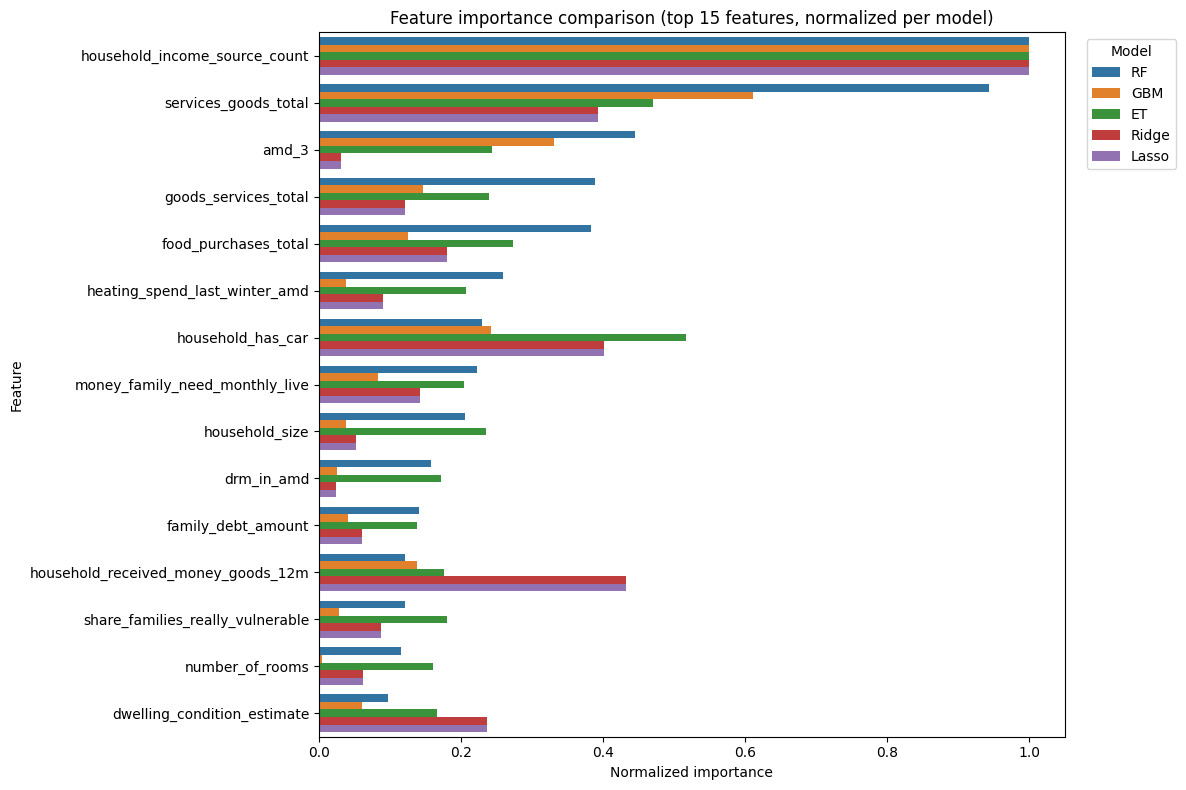

In [7]:
all_imp = imp_rf.rename(columns={"importance": "RF"}).merge(
    imp_gbm.rename(columns={"importance": "GBM"})[["feature", "GBM"]], on="feature"
).merge(
    imp_et.rename(columns={"importance": "ET"})[["feature", "ET"]], on="feature"
).merge(
    imp_ridge.rename(columns={"importance": "Ridge"})[["feature", "Ridge"]], on="feature"
).merge(
    imp_lasso.rename(columns={"importance": "Lasso"})[["feature", "Lasso"]], on="feature"
)
all_imp_norm = all_imp.copy()
for col in ["RF", "GBM", "ET", "Ridge", "Lasso"]:
    all_imp_norm[col] = all_imp_norm[col] / all_imp_norm[col].max()
top_n = 15
top_features = imp_rf.head(top_n)["feature"].tolist()
plot_df = all_imp_norm[all_imp_norm["feature"].isin(top_features)].melt(
    id_vars="feature", var_name="model", value_name="importance_norm"
)
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=plot_df, x="importance_norm", y="feature", hue="model", ax=ax)
ax.set_title(f"Feature importance comparison (top {top_n} features, normalized per model)")
ax.set_xlabel("Normalized importance")
ax.set_ylabel("Feature")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

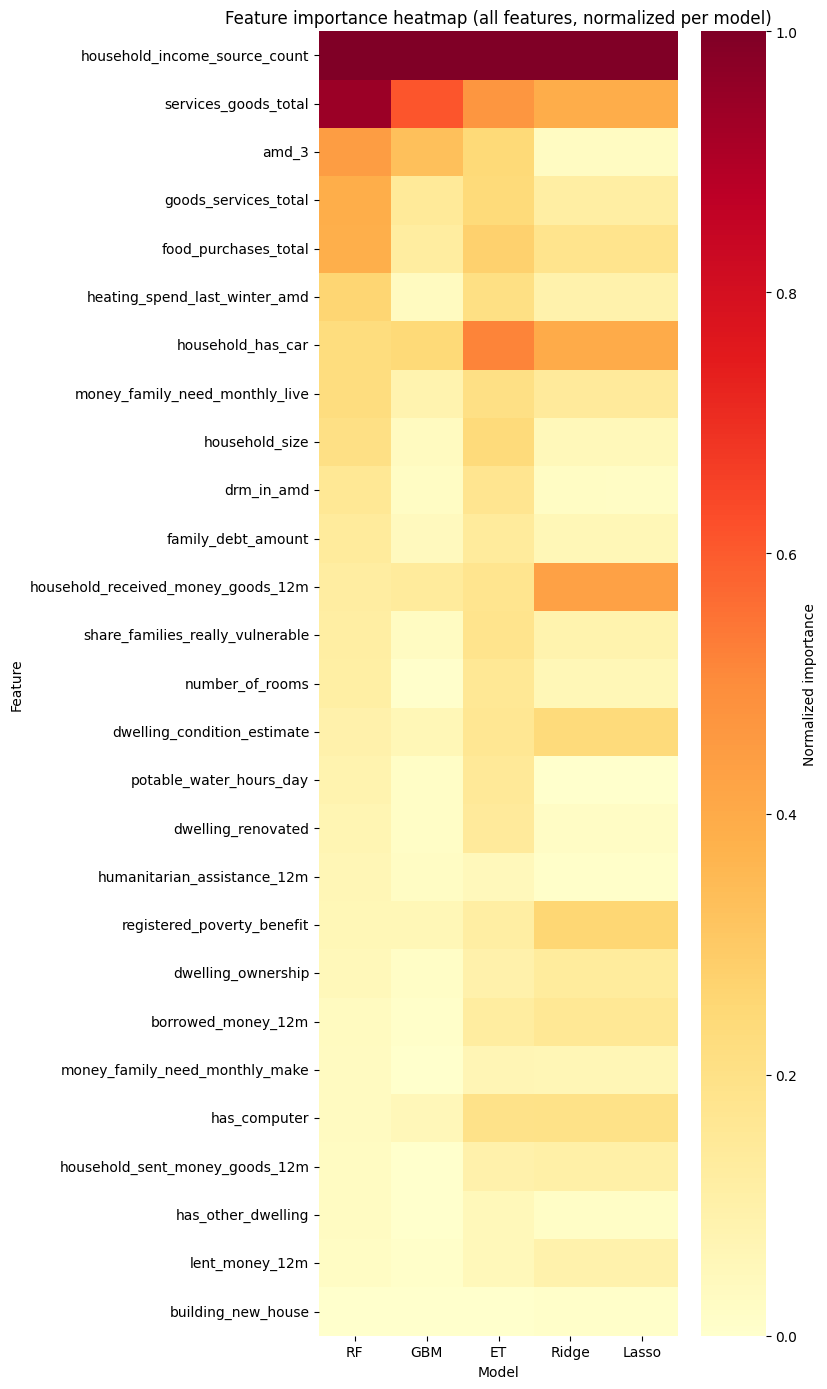

In [8]:
heatmap_df = all_imp_norm.set_index("feature")[["RF", "GBM", "ET", "Ridge", "Lasso"]]
fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(heatmap_df, annot=False, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Normalized importance"})
ax.set_title("Feature importance heatmap (all features, normalized per model)")
ax.set_xlabel("Model")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()